In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.DataFrame(columns=['concentrations', 'fluorescence1', 'fluorescence2'])
data['concentrations'] = [8,2,1.6,0.4,0.32,0.08,0.064,0.016]
data['fluorescence1'] = [3822, 417, 426, 95, 79, 16, 14, 2]
data['fluorescence2'] = [4284, 407, 424, 83, 88, 15, 16, 5]
data.set_index('concentrations', inplace=True)
data

,fluorescence1,fluorescence2
concentrations,,
8.000,3822,4284
2.000,417,407
1.600,426,424
0.400,95,83
0.320,79,88
0.080,16,15
0.064,14,16
0.016,2,5


In [12]:
degree = 1
ymeans = (data['fluorescence1'] + data['fluorescence2']) / 2
co, residuals, rank, s, rcond = np.polyfit(data.index, ymeans, deg=degree, full=True)

ypred = np.poly1d(co)(data.index)

sst = np.sum((ymeans-np.mean(ymeans))**2)
ssr = np.sum((ymeans-ypred)**2)
r2 = 1 - (ssr/sst)

print(degree, r2)

1 0.9747307986233616


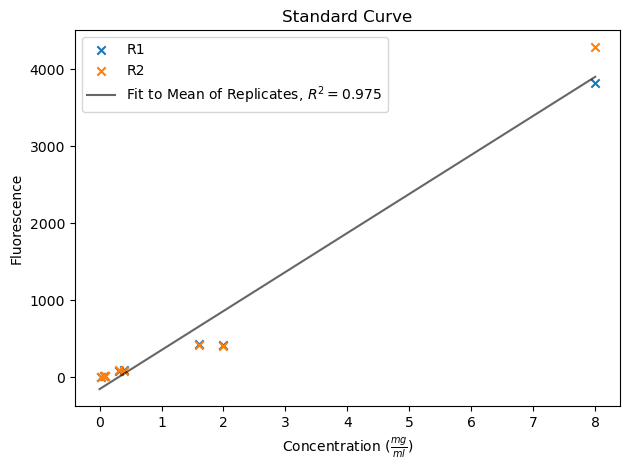

In [13]:
fig, ax = plt.subplots()
ax.scatter(data.index, data['fluorescence1'], marker='x', label='R1')
ax.scatter(data.index, data['fluorescence2'], marker='x', label='R2')
ax.plot(np.linspace(0,8,100), np.poly1d(co)(np.linspace(0,8,100)), label=r'Fit to Mean of Replicates, $R^2=$'+str(round(r2, 3)), color='k', alpha=0.6)
ax.set_ylabel('Fluorescence')
ax.set_xlabel(r'Concentration ($\frac{mg}{ml}$)')
# ax.set_yscale('log')
ax.set_title('Standard Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
samples = pd.DataFrame(columns=['x1pred','x2pred', 'x3pred', 'y1', 'y2', 'y3'])
samples['y1'] = [4402, 2354, 1161]
samples['y2'] = [4103, 4355, 4734]
samples['y3'] = [7493, 9345, 8559]

for y in [1, 2, 3]:
    for i, val in samples.iterrows(): 
        sol_coefficients = co.copy()
        sol_coefficients[-1] = co[-1] - samples.loc[i,'y'+str(y)]
        p = np.roots(sol_coefficients)
        for x in p: 
            if x > 0 and x != np.nan: 
                samples.loc[i,'x'+str(y)+'pred'] = x
samples

,x1pred,x2pred,x3pred,y1,y2,y3
0,8.985824,8.396087,15.082398,4402,4103,7493
1,4.946424,8.893123,18.735215,2354,4355,9345
2,2.593395,9.640649,17.184938,1161,4734,8559


In [15]:
print(np.mean(samples['x1pred']))
print(np.mean(samples['x2pred']))
print(np.mean(samples['x3pred']))

5.5085477415053115
8.976619602962943
17.000850326961125


In [24]:
# Average
dQdt = ((np.mean(samples['x2pred']) - np.mean(samples['x1pred'])) / (10*60) + (np.mean(samples['x3pred']) - np.mean(samples['x2pred'])) / (15*60) + (np.mean(samples['x3pred']) - np.mean(samples['x1pred'])) / (25*60)) / 3 # mg/s
Am = 1.9 # cm**2
Ca = 5 # mg/ml
c = 1 / (Am * Ca)

Papp = dQdt * c
print(Papp * 10**4)

7.844725172498291


In [31]:
samples

,x1pred,x2pred,x3pred,y1,y2,y3
0,8.985824,8.396087,15.082398,4402,4103,7493
1,4.946424,8.893123,18.735215,2354,4355,9345
2,2.593395,9.640649,17.184938,1161,4734,8559


In [32]:
# Replicates 
count = 0 
for i in samples.index: 
    count += 1
    dQdt = ((samples.loc[i, 'x2pred'] - samples.loc[i, 'x1pred']) / (10*60) + (samples.loc[i, 'x3pred'] - samples.loc[i, 'x2pred']) / (15*60) + (samples.loc[i, 'x3pred'] - samples.loc[i, 'x1pred']) / (25*60))/3 # mg/s
    Papp = dQdt * c

    print(f'Replicate {count}')
    print(f'dQ/dt: {dQdt}')
    print(f'Papp: {Papp * 10**4} * 10^-4')

Replicate 1
dQ/dt: 0.0035035743980488566
Papp: 3.6879730505777437 * 10^-4
Replicate 2
dQ/dt: 0.008902005373545836
Papp: 9.370531972153511 * 10^-4
Replicate 3
dQ/dt: 0.009951886970025437
Papp: 10.475670494763618 * 10^-4


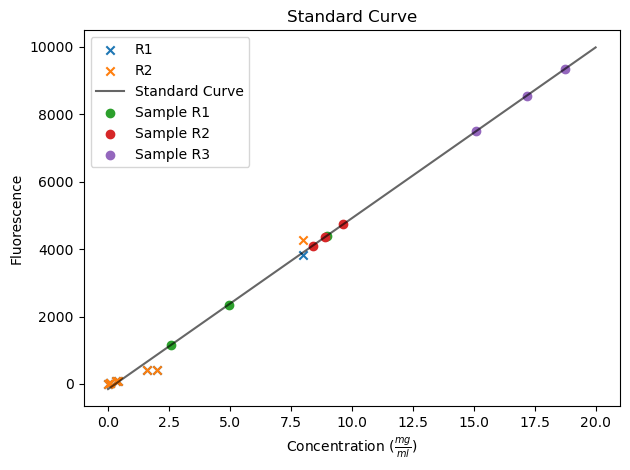

In [16]:
fig, ax = plt.subplots()

ypred_long = np.poly1d(co)(np.linspace(0,20,100))

ax.scatter(data.index, data['fluorescence1'], marker='x', label='R1')
ax.scatter(data.index, data['fluorescence2'], marker='x', label='R2')
ax.plot(np.linspace(0,20,100), ypred_long, label=r'Standard Curve', color='k', alpha=0.6)

ax.scatter(samples['x1pred'], samples['y1'], marker='o', label='Sample R1')
ax.scatter(samples['x2pred'], samples['y2'], marker='o', label='Sample R2')
ax.scatter(samples['x3pred'], samples['y3'], marker='o', label='Sample R3')

ax.set_ylabel('Fluorescence')
ax.set_xlabel(r'Concentration ($\frac{mg}{ml}$)')
# ax.set_yscale('log')
ax.set_title('Standard Curve')
ax.legend()
plt.tight_layout()
plt.show()